### Title: Exploratory Data Analysis of Shopee Listing Products Crawled in May 2023
This project analyzes Shopee listing data collected through a daily crawling process between 24 April 2023 and 13 May 2023. The analysis focuses on products listed during May 2023, handling duplicate crawls, extracting location and category information, and performing exploratory analysis on listing activity, price range, and revenue by category

### Scoping the Data Analysis Project
Business Questions:
- How many unique listing products were crawled each day during May 2023?
- How many listing products come from each location, including Malaysian states and Oversea?
- What are the main product categories represented in the Shopee listings?
- For the top 3 main categories, what are the top 5 most common subcategory_1 products?
- How do price ranges vary across different main product categories?
- Which main categories generate the highest estimated revenue?

Dataset Overview and Key Variables:
- `w_date`: Crawling date used to identify listing activity and filter products listed in May 2023
- `id`: Unique product identifiers used to detect and remove duplicate listings across multiple crawl dates
- `specification`: Product details field used to extract seller location information
- `item_category_detail`: Hierarchical category information used to derive main category, subcategory_1, and subcategory_2
- `price_ori`: Original listed price of the product
- `price_actual`: Actual price of the product after discount
- `total_sold`: Total number of units sold for each listing

Relationships Between Key Variables:
- Crawling Date vs Unique Products
  - To determine the number of unique listing products crawled on each date during May 2023
- Specification vs Listing Location
  - To extract seller location information and categorize listings by Malaysian state or as Oversea
- Item Category Hierarchy vs Number of Listings
  - To analyze the distribution of listing products across main categories and subcategories
- Main Category vs Price Range
  - To compare pricing variability and price distribution across different product categories using actual listing prices
- Main Category vs Estimated Revenue
  - To estimate and compare revenue performance across categories using actual price and total units sold


### Part 1: Data Cleaning

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('../data/20240121_shopee_sample_data_.csv')

df.head()

,price_ori,delivery,item_category_detail,specification,title,w_date,link_ori,item_rating,seller_name,idElastic,price_actual,sitename,idHash,total_rating,id,total_sold,pict_link,favorite,timestamp,desc
0,25.80,"KL City, Kuala Lumpur",Shopee | Women's Bags | Shoulder Bags | Should...,Product Specifications Category Shopee Women's...,1081 PU SLING BAG KULIT leather Casual Beg Tan...,2023-04-27,https://shopee.com.my/1081-PU-SLING-BAG-KULIT-...,4.9,qqfwholesale,19ec9fdedd9fe3e14bc652950fc3c423,12.90,shopee,88f051f0a2dcf0d29191e0175b828938,179,88f051f0a2dcf0d29191e0175b828938,179,https://down-my.img.susercontent.com/file/my-1...,Favorite (128,1682553600000,🎉 WELCOME To QQF WHOLESALE \r\n😍 ALL item read...
1,1.41,NaN,Shopee | Home Appliances | Sewing Machines | S...,Product Specifications Category Shopee Home Ap...,Stat Chinese Traditional Frog Buttons Knot Che...,2023-04-27,https://shopee.com.my/Stat-Chinese-Traditional...,5.0,stationery.my,5322309be3b6d9c01d15fa19f5b7ad9a,0.75,shopee,472d22f58af3bb35cf28c6eed7088dc5,17,472d22f58af3bb35cf28c6eed7088dc5,17,https://down-my.img.susercontent.com/file/4147...,Favorite (19,1682553600000,Chinese Traditional Frog Buttons Knot Cheongsa...
2,8.50,"KL City, Kuala Lumpur",Shopee | Women's Bags | Handbags | Set Handbags,Product Specifications Category Shopee Women's...,N09 READY STOCK MYFOOYIN woman handbag set 2in...,2023-04-26,https://shopee.com.my/N09-READY-STOCK-MYFOOYIN...,4.9,fooyin88,7a36765d1e2ca2b6a5414ddfeedfefc3,8.50,shopee,ec6ce64f4b77efb38b6392818959f181,8.1k,ec6ce64f4b77efb38b6392818959f181,8.1k,https://down-my.img.susercontent.com/file/23da...,Favorite (21.5k,1682467200000,READY STOCK\nMEASUREMENT:\nLONG 26CM X HEIGHT ...
3,8.70,NaN,Shopee | Women Clothes | Maternity Wear | Inne...,Product Specifications Category Shopee Women C...,🔥Shocking Sale🔥Cotton Comfort Nursing Bra Brea...,2023-04-26,https://shopee.com.my/%F0%9F%94%A5Shocking-Sal...,4.9,vivi2002,7fc4ab69722e4f788f217b4c044f83eb,8.70,shopee,ef4e0e17fdc7d0125d8609dcc395bc3d,6.5k,ef4e0e17fdc7d0125d8609dcc395bc3d,6.5k,https://down-my.img.susercontent.com/file/df47...,Favorite (3.4k,1682467200000,PRODUCT DESCRIPTION\nMaterial:95%Cotton+5%Span...
4,3999.00,"KL City, Kuala Lumpur",Shopee | Cameras & Drones | DSLR Cameras | DSLRs,Product Specifications Category Shopee Cameras...,Canon EOS 70D 18-55mm IS STM Original+64gb+ext...,2023-04-26,https://shopee.com.my/Canon-EOS-70D-18-55mm-IS...,5.0,xpro.gadget,55608f901f4c5384f884de18227d4298,2739.00,shopee,568c2029fed7d22973ff96d0404a8ff8,10,568c2029fed7d22973ff96d0404a8ff8,10,https://down-my.img.susercontent.com/file/4d3a...,Favorite (132,1682467200000,Canon 70D\nHighlights\nEF-S 18-55mm f/3.5-5.6 ...


In [2]:
# Initial exploration and identify the missing values
display(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 20312 entries, 0 to 20311
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_ori             20112 non-null  float64
 1   delivery              6558 non-null   str    
 2   item_category_detail  20312 non-null  str    
 3   specification         20301 non-null  str    
 4   title                 20312 non-null  str    
 5   w_date                20312 non-null  str    
 6   link_ori              20312 non-null  str    
 7   item_rating           20301 non-null  str    
 8   seller_name           20301 non-null  str    
 9   idElastic             20312 non-null  str    
 10  price_actual          20297 non-null  float64
 11  sitename              20312 non-null  str    
 12  idHash                20312 non-null  str    
 13  total_rating          20301 non-null  str    
 14  id                    20312 non-null  str    
 15  total_sold            20301 no

None

note: 
- w_date should be in datetime format
- total_sold should be convert into integers with numerical values instead of 'k'


In [3]:
# Convert 'total_sold' from string to integer, handling values with 'k'
def get_total_sold_int(value):
    if pd.isnull(value):
        return None
    
    value = str(value).lower().strip()

    if 'k' in value:
        return int(float(value.replace('k','')) * 1000)
    else:
        return int(float(value))

df['total_sold'] = df['total_sold'].apply(get_total_sold_int).astype('Int64')

# Convert 'w_date' to datetime for proper date filtering
df['w_date'] = pd.to_datetime(df['w_date'], errors='coerce')

# Check the dtype
df[['w_date','total_sold']].info()

<class 'pandas.DataFrame'>
RangeIndex: 20312 entries, 0 to 20311
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   w_date      20312 non-null  datetime64[us]
 1   total_sold  20301 non-null  Int64         
dtypes: Int64(1), datetime64[us](1)
memory usage: 337.3 KB


Task 1: Filter data by products listed in May 2023

In [4]:
# Filter data to include only products listed in May 2023
df_may = df[(df['w_date'] >= '2023-05-01') & (df['w_date'] <= '2023-05-31')]
df_may.shape

(16854, 20)

In [6]:
# Check total duplicates
df_may.duplicated().sum()

np.int64(0)

In [7]:
# Keep only relevant columns for analysis
cols_to_keep = [
    'id', 'w_date', 'specification', 'item_category_detail',
    'price_ori', 'price_actual', 'total_sold'
    ]

df_may_clean = df_may[cols_to_keep].copy()
df_may_clean.shape

(16854, 7)

In [8]:
df_may_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 16854 entries, 3458 to 20311
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    16854 non-null  str           
 1   w_date                16854 non-null  datetime64[us]
 2   specification         16845 non-null  str           
 3   item_category_detail  16854 non-null  str           
 4   price_ori             16716 non-null  float64       
 5   price_actual          16843 non-null  float64       
 6   total_sold            16846 non-null  Int64         
dtypes: Int64(1), datetime64[us](1), float64(2), str(3)
memory usage: 938.3 KB


In [9]:
# Check missing values
print('Missing values:\n', df_may_clean.isnull().sum())

# Check missing values percentage
nullpercentage = df_may_clean.isnull().sum()/df_may_clean.shape[0]*100
print('\nPercentage of missing values:\n', nullpercentage)

Missing values:
 id                        0
w_date                    0
specification             9
item_category_detail      0
price_ori               138
price_actual             11
total_sold                8
dtype: int64

Percentage of missing values:
 id                      0.000000
w_date                  0.000000
specification           0.053400
item_category_detail    0.000000
price_ori               0.818797
price_actual            0.065266
total_sold              0.047466
dtype: float64


Notes:
- There are 4 features having missing values with small percentages. We may proceed with imputation. 
- Three features are numerical features. We will proceed these three features with imputation. Is it necessary to check numerical frequency by category as the values may different by categories.
- One feature, specification, is a categorical feature. Since the percentage is too small and drop means deleting the count of product lisitng, we will proceed with filling the null as 'Unknown'

1. Handling Numerical Features

In [10]:
df_may_clean.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
price_ori,16716.0,120142.747629,10937945.793625,0.0,2.3,21.99,99.61,999999999.0
price_actual,16843.0,119178.984823,10896633.444294,0.0,1.0,12.34,79.0,999999999.0
total_sold,16846.0,1278.509023,4783.489401,0.0,30.0,169.0,811.0,197200.0


Notes: price_ori and price_actual having high maximum values and low values at 75%. These high values might be outliers

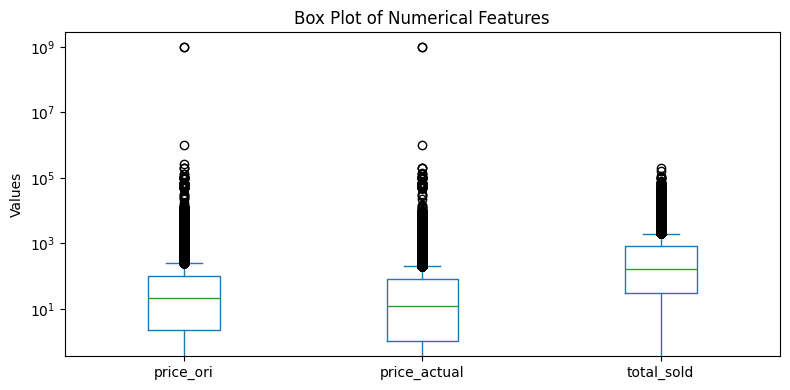

In [11]:
df_numerical = df_may_clean[['price_ori','price_actual','total_sold']].copy()
df_numerical.plot(kind='box', figsize=(8,4))
plt.yscale('log')
plt.title('Box Plot of Numerical Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

Notes: Overall, there are many outliers for price_ori and price_actual.However, further analysis should be conducted to check whether these outliers are acceptable or should be imputated

In [12]:
price_outliers = df_may_clean[df_may_clean['price_ori']>=1000000]
price_outliers

,id,w_date,specification,item_category_detail,price_ori,price_actual,total_sold
8168,0a069dba94f3badb8afa8ba9bc29118f,2023-05-13,Product Specifications Category Shopee Home Ap...,Shopee | Home Appliances | Landline Phones | C...,999999999.0,999999999.0,0
8676,0a069dba94f3badb8afa8ba9bc29118f,2023-05-07,Product Specifications Category Shopee Home Ap...,Shopee | Home Appliances | Landline Phones | C...,999999999.0,999999999.0,0
10286,6b6ae8252fd32d7035f96ca846f00cb3,2023-05-12,Product Specifications Category Shopee Home Ap...,Shopee | Home Appliances | Others | Others,1000000.0,1000000.0,111


Notes: There are three rows having high values for prices. 1000000 seems not an outlier since there are 111 values sold.Let's check on the 999999999.0

In [13]:
pd.set_option('display.max_colwidth', None)
price_outliers[['item_category_detail']]

,item_category_detail
8168,Shopee | Home Appliances | Landline Phones | Cordless Phone
8676,Shopee | Home Appliances | Landline Phones | Cordless Phone
10286,Shopee | Home Appliances | Others | Others


In [14]:
# Check data distribution for 'item_category_detail' having price 999999999.0
price = df_may_clean[['item_category_detail', 'price_ori','price_actual','total_sold']].copy()
price_before = price[price['item_category_detail']== 'Shopee | Home Appliances | Landline Phones | Cordless Phone']
price_before[['price_ori','price_actual','total_sold']].astype(int)

,price_ori,price_actual,total_sold
4307,439,439,0
4373,435,435,0
5368,739,369,0
5658,254,207,0
5782,5,2,0
6447,5,2,0
6597,358,251,0
6760,165,165,0
6836,5,3,0
6932,459,459,0


In [15]:
price_before.describe().T

,count,mean,std,min,25%,50%,75%,max
price_ori,22.0,90909546.289545,294244795.452785,5.07,186.125,437.0,509.0,999999999.0
price_actual,22.0,90909518.569091,294244804.425054,2.81,167.48,432.5,501.5,999999999.0
total_sold,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Notes: There is only 2 rows have extreme high value which confirmed as outliers. Both price_ori and price_actual have small values for minimum and at 75%, so we will imputate the outliers with a median respectively.

1.1 Imputation the null values and extreme outliers - price_ori

In [16]:
# Treat extreme outliers as null
df_may_clean['price_ori'] = df_may_clean['price_ori'].replace(999999999.0, np.nan)

# Category-level median imputation
df_may_clean['price_ori'] = df_may_clean['price_ori'].fillna(
    df_may_clean.groupby('item_category_detail')['price_ori'].transform('median')
)

# Fillna for price_ori with category-level median imputation
df_may_clean['price_ori'] = df_may_clean['price_ori'].fillna(df_may_clean['price_ori'].median())

1.2 Imputation the null values and extreme outliers - price_actual

In [17]:
df_may_clean['price_actual'] = df_may_clean['price_actual'].replace(999999999.0,np.nan)

df_may_clean['price_actual'] = df_may_clean['price_actual'].fillna(
    df_may_clean.groupby('item_category_detail')['price_actual'].transform('median')
)

df_may_clean['price_actual'] = df_may_clean['price_actual'].fillna(df_may_clean['price_actual'].median())

In [18]:
# Validate the transformed data
price_after = df_may_clean[['item_category_detail', 'price_ori','price_actual','total_sold']].copy()
price_after = price_after[price_after['item_category_detail']== 'Shopee | Home Appliances | Landline Phones | Cordless Phone']
price_after[['price_ori','price_actual','total_sold']].astype(int)

,price_ori,price_actual,total_sold
4307,439,439,0
4373,435,435,0
5368,739,369,0
5658,254,207,0
5782,5,2,0
6447,5,2,0
6597,358,251,0
6760,165,165,0
6836,5,3,0
6932,459,459,0


1.3 Handling null values - total_sold

In [19]:
df_may_clean.isnull().sum()

id                      0
w_date                  0
specification           9
item_category_detail    0
price_ori               0
price_actual            0
total_sold              8
dtype: int64

In [20]:
sold = df_may_clean[['item_category_detail', 'price_ori','price_actual','total_sold']].copy()
sold[sold['total_sold'].isnull()].drop(columns='total_sold')

,item_category_detail,price_ori,price_actual
4673,"Shopee | Automotive | Motor Accessories | Stickers, Logos & Emblems",0.0,0.0
8489,Shopee | Women Clothes | Skirts | Others,0.0,0.0
8664,Shopee | Tickets & Vouchers | F&B Vouchers | Others,0.0,0.0
10340,Shopee | Men's Bags & Wallets | Tote Bags | Tote Bags,0.0,0.0
10806,Shopee | Women Clothes | Others | Others,0.0,0.0
12612,Shopee | Women's Bags | Others | Others,0.0,0.0
15794,Shopee | Men's Bags & Wallets | Tote Bags | Tote Bags,0.0,0.0
20011,Shopee | Women Clothes | Skirts | Others,0.0,0.0


Notes: Missing values for total_sold have 0 price_ori and price_actual which we may indicates total_sold also have 0 values for null rows

In [21]:
df_may_clean['total_sold'] = df_may_clean['total_sold'].fillna(0)
df_may_clean.isnull().sum()

id                      0
w_date                  0
specification           9
item_category_detail    0
price_ori               0
price_actual            0
total_sold              0
dtype: int64

Notes: specification is a categorical feature. We will fill the missing values alongside with splitting into categories

### Part 2: Data Manipulation

In [22]:
df_may_clean.head()

,id,w_date,specification,item_category_detail,price_ori,price_actual,total_sold
3458,39e46146e50e47e973654c91b5c174ad,2023-05-05,Product Specifications Category Shopee Cameras & Drones Mirrorless Cameras Mirrorless Cameras Condition Used BrandCanon Stock 1 Ships From Thailand,Shopee | Cameras & Drones | Mirrorless Cameras | Mirrorless Cameras,23351.90,23351.90,0
3459,ff5aa7e775e004eef451df6d114e6b4a,2023-05-02,Product Specifications Category Shopee Home & Living Housekeeping & Laundry Cleaning Tools Stock 9457 Ships From Penang,Shopee | Home & Living | Housekeeping & Laundry | Cleaning Tools,0.15,0.15,7
3460,21067e40e05ecffd84c06a7516ee1512,2023-05-02,Product Specifications Category Shopee Groceries & Pets Baking Supplies Toppings & Decoration Stock 2533 Ships From Penang,Shopee | Groceries & Pets | Baking Supplies | Toppings & Decoration,0.70,0.70,2100
3461,c5c746c917339cc15c75acb02bc1f83b,2023-05-02,Product Specifications Category Shopee Groceries & Pets Food Staple Noodle & Vermicelli Stock 1149 Ships From Melaka,Shopee | Groceries & Pets | Food Staple | Noodle & Vermicelli,2.10,1.60,1100
3462,48a54782318c7d6a7e02f9bdc2f3930a,2023-05-02,Product Specifications Category Shopee Home & Living Kitchen & Dining Kitchen Tools Stock 2825 Ships From Selangor,Shopee | Home & Living | Kitchen & Dining | Kitchen Tools,0.19,0.19,15


In [23]:
df_may_clean.shape

(16854, 7)

Q1 : Product Listings in May 2023

The dataset contains daily crawl snapshots means the same product may appear multiple times with different prices. To decide which price represents the product, we decided to use latest date snapshot

In [24]:
# Product listings exclude product id having crawled multiple days
df_list = df_may_clean.copy()
df_list = df_list.sort_values("w_date").drop_duplicates("id", keep="last")
df_list.duplicated().sum()

np.int64(0)

In [25]:
# Total product listings in May 2023
#df_list.shape[0]

pd.DataFrame({'Total Product Listings in May 2023': [df_list.shape[0]]})

,Total Product Listings in May 2023
0,14259


Notes:
- We drop duplicates based on id because the dataset contains daily crawl snapshots, and the same product may appear multiple times across different dates
- Since Q1 asks for listed products during May 2023, we must count each product only once

Q2: Number of Unique Products Crawled per Day

In [26]:
crawler_daily_counts = df_may_clean.groupby('w_date')['id'].nunique().reset_index()
crawler_daily_counts.rename(columns={'id': 'number_of_products'}, inplace=True)
print('Number of unique products crawled per day in May 2023:')
display(crawler_daily_counts)

Number of unique products crawled per day in May 2023:


,w_date,number_of_products
0,2023-05-01,3646
1,2023-05-02,466
2,2023-05-03,985
3,2023-05-04,201
4,2023-05-05,852
5,2023-05-06,747
6,2023-05-07,583
7,2023-05-08,774
8,2023-05-09,571
9,2023-05-10,904


Notes:
- Q2 measures crawl activity per date, so we must use raw data because each row represents a crawl event
- If we deduplicate by product id first, we would remove valid crawl records and undercount the crawling volume

Q3. Number of Products per Location

In [27]:
# Add new 'ships_from' column by splitting 'ships from %%' in specification to identify Malaysian states
def get_ships_from(spec):
    if pd.isnull(spec):
        return None
    if 'Ships From' in spec:
        return spec.split('Ships From')[1].strip()
    else:
        return None

df_list['ships_from'] = df_list['specification'].apply(get_ships_from)
df_list['ships_from'].unique()

<StringArray>
[                             'Mainland China',
                                    'Selangor',
                                       'Johor',
                                      'Melaka',
                                    'Kelantan',
                                'Kuala Lumpur',
                   'Shah Alam, 40300 Selangor',
                                   'Indonesia',
                             'Negeri Sembilan',
                                      'Penang',
 ...
                         'Baling, 09200 Kedah',
            'Kuala Lumpur, 40170 Kuala Lumpur',
 'KAB. SRAGEN - SUMBERLAWANG, JAWA TENGAH, ID',
            'Kuala Lumpur, 50050 Kuala Lumpur',
              'Kuala Selangor, 42600 Selangor',
                'Kuala Langat, 43500 Selangor',
                    'Johor Bahru, 79967 Johor',
               'Petaling Jaya, 47830 Selangor',
            'Kuala Lumpur, 54200 Kuala Lumpur',
  'W.P. Kuala Lumpur, 50000 W.P. Kuala Lumpur']
Length: 399, dtype: s

In [28]:
# Add new 'location' column to categorized locations into Malaysian states or Oversea
malaysia_states = {
    'Johor': 'Johor',
    'Kedah': 'Kedah',
    'Kelantan': 'Kelantan',
    'Melaka': 'Melaka',
    'Negeri Sembilan': 'Negeri Sembilan',
    'Pahang': 'Pahang',
    'Penang': 'Penang',
    'Pulau Pinang': 'Penang',   # map to Penang
    'Perak': 'Perak',
    'Perlis': 'Perlis',
    'Sabah': 'Sabah',
    'Sarawak': 'Sarawak',
    'Selangor': 'Selangor',
    'Terengganu': 'Terengganu',
    'Kuala Lumpur': 'Kuala Lumpur',
    'Putrajaya': 'Putrajaya'
}

def get_location (ships_from):
    if pd.isnull(ships_from):
        return None
    for states in malaysia_states:
        if states.lower() in ships_from.lower():
            return malaysia_states[states]
    else:
        return 'Oversea'
    
df_list['location'] = df_list['ships_from'].apply(get_location)
df_list['location'].unique()

<StringArray>
[        'Oversea',        'Selangor',           'Johor',          'Melaka',
        'Kelantan',    'Kuala Lumpur', 'Negeri Sembilan',          'Penang',
           'Kedah',          'Pahang',           'Perak',          'Perlis',
           'Sabah',      'Terengganu',       'Putrajaya',         'Sarawak',
               nan]
Length: 17, dtype: str

In [29]:
# Number of products by location
products_by_location = df_list['location'].value_counts().reset_index(name='number_of_products')
products_by_location

,location,number_of_products
0,Selangor,4959
1,Oversea,2162
2,Kuala Lumpur,2034
3,Johor,1041
4,Perak,949
5,Penang,936
6,Kedah,423
7,Negeri Sembilan,400
8,Kelantan,336
9,Melaka,316


Notes:

- Extracted the `ships_from` information from the `specification` field to identify seller locations
- Categorized each location into Malaysian states or Oversea to standardize the data for analysis by location


Q4. Number of Products by Main Category and Subcategory

In [30]:
# Drop unrelevant columns
df_list.drop(columns=['specification','ships_from'], inplace=True)
df_list.head()

,id,w_date,item_category_detail,price_ori,price_actual,total_sold,location
6315,809bb354908d4f7f2fc80cb1478a4576,2023-05-01,Shopee | Men Clothes | Sets | Occupational Attire,98.00,35.80,2400,Oversea
6721,44ea5121859303667696381aa2bc1548,2023-05-01,Shopee | Baby & Toys | Nursery | Blankets & Wrappers,40.00,13.90,15400,Selangor
6720,55f2f87dd843252f91fc2d4685c262a9,2023-05-01,Shopee | Groceries & Pets | Instant Food | Instant Noodle & Pasta,0.80,0.80,34,Selangor
6719,980f6de8359bc86f0e2d9d713ed68ec1,2023-05-01,"Shopee | Home & Living | Bath | Mats, Towels & Robes",0.93,0.91,56,Johor
6718,9f38ddd2c6b33caeb5d69fbb68586567,2023-05-01,Shopee | Home & Living | Bath | Others,3.00,1.45,1900,Selangor


In [31]:
# Split 'item_category_detail' into main category and subcategory
category_split = df_list['item_category_detail'].str.split('|', expand=True)
category_split = category_split.apply(lambda x: x.str.strip())

df_list['main_category'] = category_split[1]
df_list['subcategory_1'] = category_split[2]
df_list['subcategory_2'] = category_split[3]

df_list.head()

,id,w_date,item_category_detail,price_ori,price_actual,total_sold,location,main_category,subcategory_1,subcategory_2
6315,809bb354908d4f7f2fc80cb1478a4576,2023-05-01,Shopee | Men Clothes | Sets | Occupational Attire,98.00,35.80,2400,Oversea,Men Clothes,Sets,Occupational Attire
6721,44ea5121859303667696381aa2bc1548,2023-05-01,Shopee | Baby & Toys | Nursery | Blankets & Wrappers,40.00,13.90,15400,Selangor,Baby & Toys,Nursery,Blankets & Wrappers
6720,55f2f87dd843252f91fc2d4685c262a9,2023-05-01,Shopee | Groceries & Pets | Instant Food | Instant Noodle & Pasta,0.80,0.80,34,Selangor,Groceries & Pets,Instant Food,Instant Noodle & Pasta
6719,980f6de8359bc86f0e2d9d713ed68ec1,2023-05-01,"Shopee | Home & Living | Bath | Mats, Towels & Robes",0.93,0.91,56,Johor,Home & Living,Bath,"Mats, Towels & Robes"
6718,9f38ddd2c6b33caeb5d69fbb68586567,2023-05-01,Shopee | Home & Living | Bath | Others,3.00,1.45,1900,Selangor,Home & Living,Bath,Others


Q4a. Number of Products by Main Category

In [32]:
products_by_main_category = df_list['main_category'].value_counts().reset_index(name='number_of_products')
products_by_main_category

,main_category,number_of_products
0,Health & Beauty,1563
1,Men Clothes,1487
2,Women Clothes,1370
3,Baby & Toys,1157
4,Mobile & Accessories,1150
5,Home & Living,837
6,Groceries & Pets,827
7,Home Appliances,724
8,Sports & Outdoor,654
9,Automotive,606


Notes:
- Split the `item_category_detail` column into `main_category`, `subcategory_1`, and `subcategory_2` to separate hierarchical category information 
- Dropped irrelevant columns (`specification`, `ships_from`) to focus the dataset on product categories and sales data for analysis

Q4b. Top 5 Number of Products in Subcategory_1 for the Top 3 Main Categories

In [33]:
# Top 3 main category
top3_main_cat = df_list['main_category'].value_counts().head(3).index
df_top3 = df_list[df_list['main_category'].isin(top3_main_cat)]

# Group by top 3 main and get top 5 subcategory_1 for each
top5_subcategory_1 = (
    df_top3.groupby('main_category')['subcategory_1']
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name='number_of_products')
)

top5_subcategory_1

,main_category,subcategory_1,number_of_products
0,Health & Beauty,Sun Care,101
1,Health & Beauty,Medical Supplies,100
2,Health & Beauty,Bath & Body,95
3,Health & Beauty,Personal Pleasure,94
4,Health & Beauty,Pedicure & Manicure,93
5,Men Clothes,Sets,191
6,Men Clothes,Others,130
7,Men Clothes,Pants,125
8,Men Clothes,Suits,121
9,Men Clothes,Shirts,108


Notes:
- Filtered the dataset to include only the top 3 main categories by number of products
- Grouped by `main_category` and `subcategory_1` to identify the top 5 subcategories in each main category, providing a more detailed view of product distribution within the top 3 main categories

Q5. Price Range per Main Category

In [34]:
# Descriptive statistics
df_list.select_dtypes(include='number').describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
price_ori,14259.0,408.17013,9346.523318,0.0,2.425,21.9,99.0,1000000.0
price_actual,14259.0,350.074863,9117.740491,0.0,1.0,12.0,76.74,1000000.0
total_sold,14259.0,1286.83414,4848.121099,0.0,31.0,169.0,821.0,197200.0


Note:
- price_ori and price_actual have high maximum values, which may indicate outliers

In [35]:
# Price range for each main category
price_range = (
    df_list.groupby('main_category')['price_actual']
    .agg(['min','max','median','mean'])
    .reset_index()
    #.sort_values('min')
    #.sort_values(by='max', ascending=False)
)
price_range['max'] = price_range['max'].astype(int)
price_range

,main_category,min,max,median,mean
0,Automotive,0.00,205500,1.900,2323.673251
1,Baby & Toys,0.00,99999,3.200,241.223695
2,Cameras & Drones,0.10,28451,17.250,943.056624
3,Computer & Accessories,0.10,12349,9.200,366.954294
4,Fashion Accessories,0.10,999,2.995,21.681429
5,"Games, Books & Hobbies",0.10,999,1.620,28.373191
6,Gaming & Consoles,0.10,949,0.990,53.317607
7,Groceries & Pets,0.08,9999,14.000,91.038573
8,Health & Beauty,0.10,10000,3.990,65.777575
9,Home & Living,0.07,999,6.790,35.893047


Notes:
- Calculated the minimum and maximum `price_actual` for each main category to summarize the price range across product categories
- We used price_actual instead of price_ori because it reflects the actual selling price after discount, which better represents the market price customers pay

Q6. Highest Revenue per Main Category

In [36]:
# Drop unrelevant column
df_list.drop(columns='item_category_detail', inplace=True)

# Add new calculated 'revenue' column
df_list['revenue'] = df_list['price_actual'] * df_list['total_sold']

revenue_by_category = (
    df_list
    .groupby('main_category')
    .agg(
        total_sold=('total_sold', 'sum'),
        total_revenue=('revenue', 'sum')
        
    )
    .sort_values(by='total_revenue', ascending=False)
    .reset_index()
)

revenue_by_category

,main_category,total_sold,total_revenue
0,Home Appliances,711546,206142266.5
1,Health & Beauty,2838919,144326003.0
2,Baby & Toys,2017071,123228970.18
3,Mobile & Accessories,1895122,98801043.11
4,Home & Living,2263719,63123978.52
5,Groceries & Pets,1324937,62962172.6
6,Men Clothes,1650003,32132027.99
7,Computer & Accessories,278889,29024185.81
8,Automotive,1181152,26096512.99
9,Sports & Outdoor,428614,23769094.86


Notes:
- Calculated a new `revenue` column as `price_actual * total_sold` for each product to estimate total earnings 
- Aggregated revenue by `main_category` and sorted in descending order to identify categories generating the highest estimated revenue


Part 3: Data Visualization

1. Daily Trend of Products Crawled in May 2023

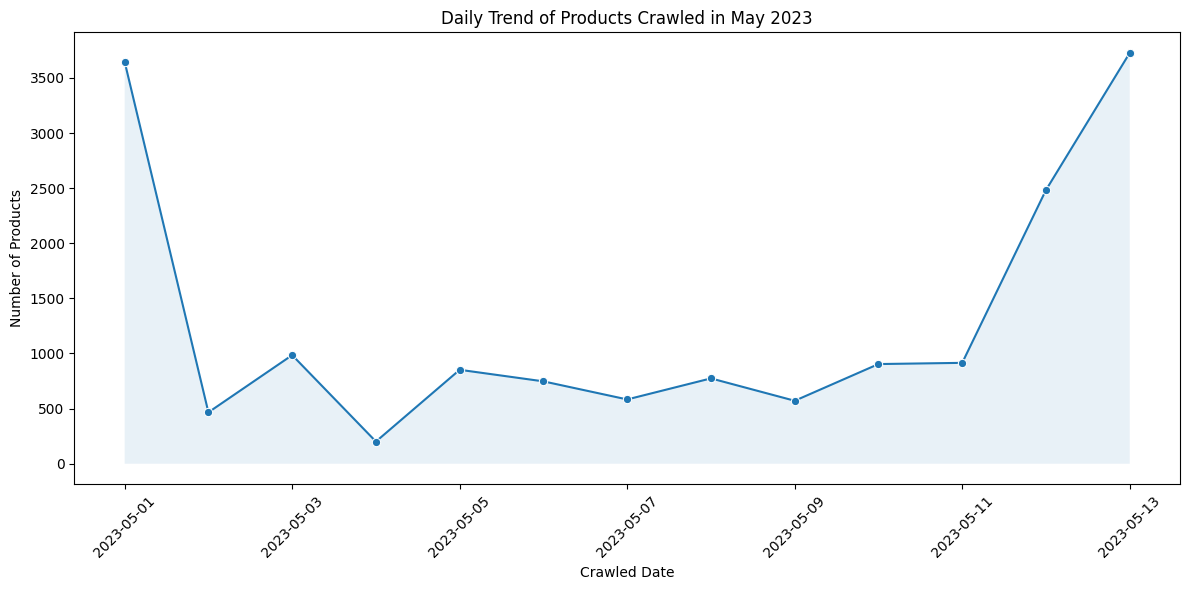

In [37]:
# Plot line chart
plt.figure(figsize=(12,6))
sns.lineplot(x='w_date', y='number_of_products', data=crawler_daily_counts, marker='o')
plt.fill_between(crawler_daily_counts['w_date'], 
                 crawler_daily_counts['number_of_products'], alpha=0.1)
plt.title('Daily Trend of Products Crawled in May 2023')
plt.xlabel('Crawled Date')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Insights:
- The crawl volume peaked on May 1st and May 13th, with over 3,000 products collected on the highest days
- Other days generally had lower crawl activity, often under 1,000 products, with the lowest on May 4th
- The trend shows fluctuations in daily crawling, which may reflect batch crawling schedules or system performance


2. Product Distribution by Location

C:\Users\marya\AppData\Local\Temp\ipykernel_17528\1485827837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y='number_of_products', data=products_by_location, palette='viridis')


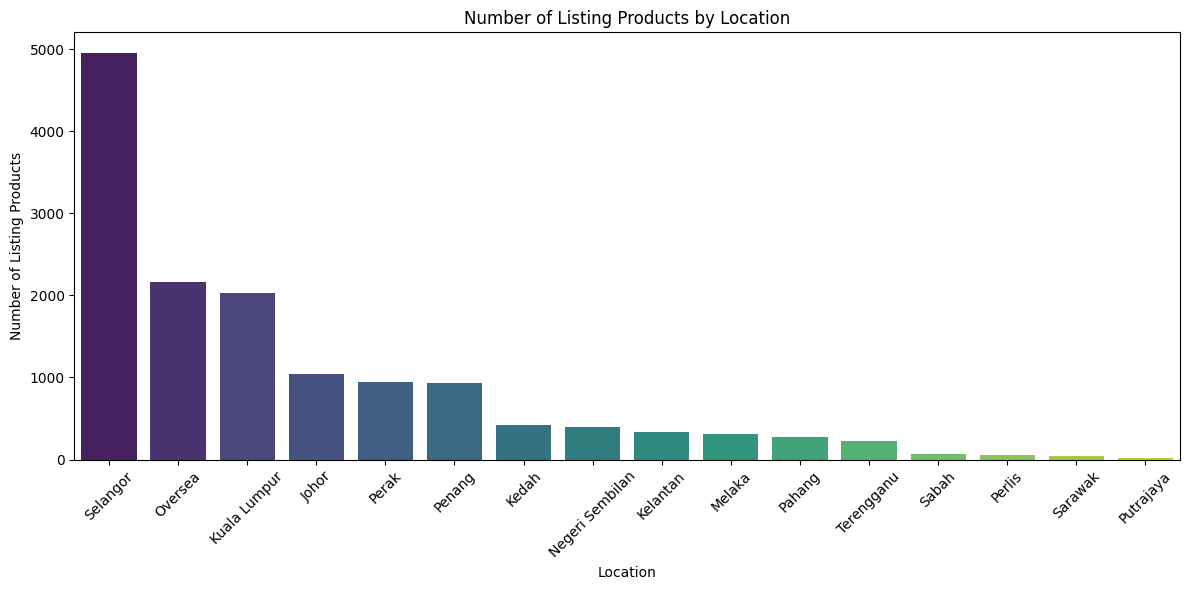

In [38]:
# Plot bar chart
plt.figure(figsize=(12,6))
sns.barplot(x='location', y='number_of_products', data=products_by_location, palette='viridis')
plt.xticks(rotation=45)
plt.title('Number of Listing Products by Location')
plt.xlabel('Location')
plt.ylabel('Number of Listing Products')
plt.tight_layout()
plt.show()

Insights:
- Product listings are heavily concentrated in urban and high-population areas such as Selangor, Kuala Lumpur, and Johor
- Oversea sellers represent a significant portion, highlighting the platform’s international reach
- States like Perak, Penang, and Kedah have moderate listings, while states such as Perlis, Sarawak, and Putrajaya have very few products, indicating lower seller participation in these regions

3. Proportion of Products by Location Group

In [39]:
# Group locations into Malaysia / Oversea / Unknown
def group_location(x):
    if pd.isnull(x):
        return 'Unknown'
    elif x == 'Oversea':
        return 'Oversea'
    else:
        return 'Malaysia'

df_list['location_group'] = df_list['location'].apply(group_location)

# Create table with counts and percentages
products_by_group = df_list['location_group'].value_counts().reset_index()
products_by_group.columns = ['location_group', 'number_of_products']

# Calculate percentage
total_products = products_by_group['number_of_products'].sum()
products_by_group['percentage'] = (products_by_group['number_of_products'] / total_products * 100).round(1)

products_by_group

,location_group,number_of_products,percentage
0,Malaysia,12067,84.6
1,Oversea,2162,15.2
2,Unknown,30,0.2


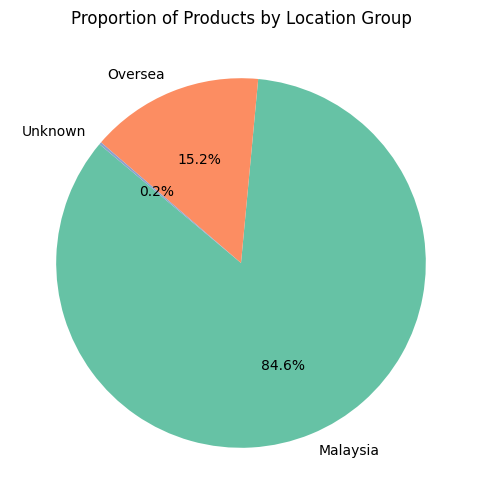

In [40]:
# Plot pie chart 
plt.figure(figsize=(6,6))
plt.pie(
    products_by_group['number_of_products'],
    labels=products_by_group['location_group'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66c2a5', '#fc8d62', '#8da0cb'] 
)
plt.title('Proportion of Products by Location Group')
plt.show()


Insights:
- The platform is predominantly supplied by Malaysian sellers
- Oversea products form a smaller segment, highlighting the presence of international listings
- A very small number of products have Unknown locations, likely due to missing or incomplete seller information or unrecorded entries

4. Product Distribution by Main Category

C:\Users\marya\AppData\Local\Temp\ipykernel_17528\2829657579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='number_of_products', y='main_category', data=products_by_main_category, palette='viridis')


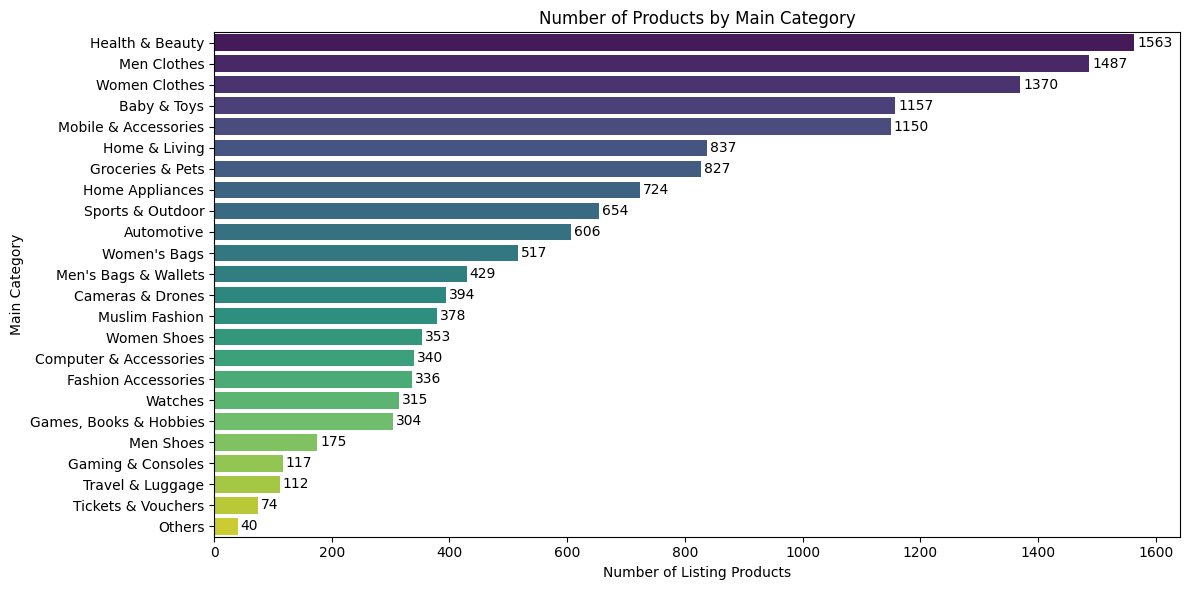

In [41]:
# Plot horizontal bar chart
plt.figure(figsize=(12,6))
sns.barplot(x='number_of_products', y='main_category', data=products_by_main_category, palette='viridis')

products_sorted = products_by_main_category.sort_values('number_of_products', ascending=False)
for index, value in enumerate(products_sorted['number_of_products']):
    plt.text(value + 5, index, str(value), va='center')

plt.title('Number of Products by Main Category')
plt.xlabel('Number of Listing Products')
plt.ylabel('Main Category')
plt.tight_layout()
plt.show()

Insights:
- Health & Beauty and apparel categories dominate the listings, indicating strong consumer interest in personal care and fashion
- Baby & Toys, Mobile & Accessories, and Home & Living have a moderate number of products, reflecting steady supply in essential and lifestyle categories
- Less represented categories like Tickets & Vouchers has very few listings, suggesting these categories attract fewer sellers and products

5. Top 5 Subcategory 1 Products for Top 3 Main Categories

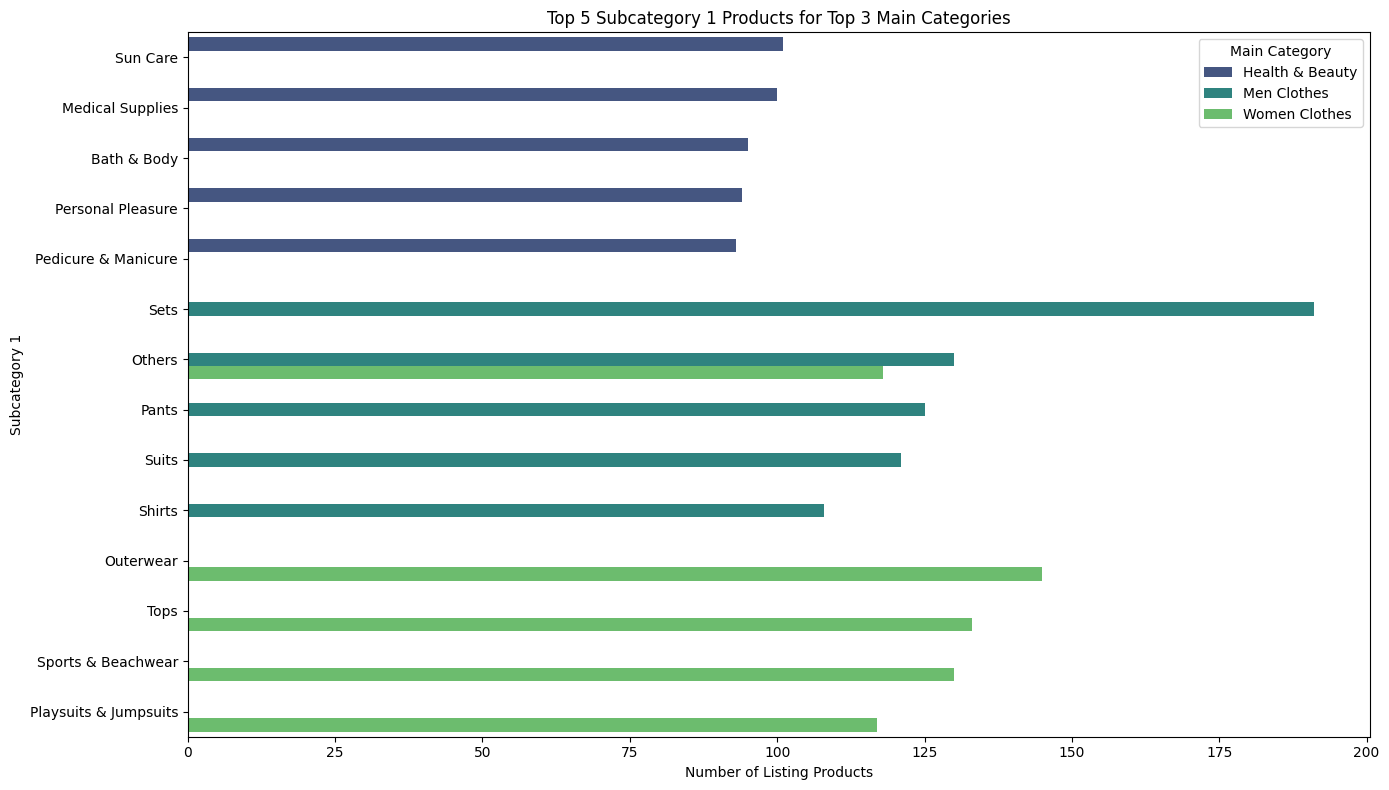

In [42]:
# Plot grouped bar chart
plt.figure(figsize=(14,8))
sns.barplot(x='number_of_products', y='subcategory_1', hue='main_category', data=top5_subcategory_1, palette='viridis')
plt.title('Top 5 Subcategory 1 Products for Top 3 Main Categories')
plt.xlabel('Number of Listing Products')
plt.ylabel('Subcategory 1')
plt.legend(title='Main Category')
plt.tight_layout()
plt.show()


Insights:
- Each main category is dominated by a few high-performing subcategories, reflecting specific product preferences among sellers
- Subcategories such as Sun Care, Sets and Outerwear show concentrated listings, suggesting these are popular segments within their main categories
- Subcategory like Others represent a mix of smaller or less common products, including items that are not part of the top listed subcategories

6. Price Range per Main Category

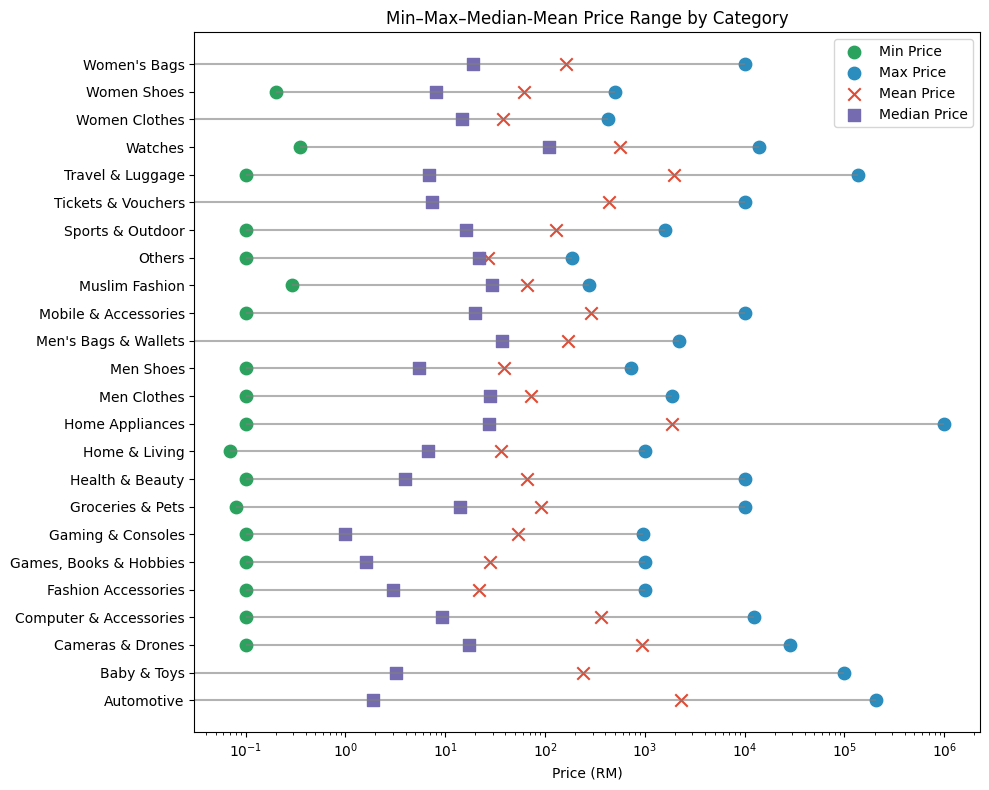

In [43]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

color_min = '#2ca25f'
color_max = '#2b8cbe'
color_mean = '#e34a33'
color_median = '#756bb1'

# Min
plt.scatter(price_range['min'], price_range['main_category'],
            color=color_min, label='Min Price', s=80)

# Max
plt.scatter(price_range['max'], price_range['main_category'],
            color=color_max, label='Max Price', s=80)

# Mean
plt.scatter(price_range['mean'], price_range['main_category'],
            color=color_mean, label='Mean Price', s=80, marker='x')

# Median
plt.scatter(price_range['median'], price_range['main_category'],
            color=color_median, label='Median Price', s=80, marker='s')

# Range line
plt.hlines(
    y=price_range['main_category'],
    xmin=price_range['min'],
    xmax=price_range['max'],
    alpha=0.6,
    color='grey'
)

plt.xscale('log')
plt.xlabel('Price (RM)')
plt.title('Min–Max–Median-Mean Price Range by Category')
plt.legend()
plt.tight_layout()
plt.show()

Insights:
- High-value category like Home Appliances contributes to wider price variability, which may drive revenue through specialty products despite fewer listings
- Categories with narrower price ranges like Health & Beauty and Home & Living tend to rely on volume-based sales rather than high unit prices
- In many categories, the mean price is higher than the median, indicating right-skewed distributions driven by a small number of high-priced products

7. Estimated Revenue per Main Category

C:\Users\marya\AppData\Local\Temp\ipykernel_17528\3471209662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='main_category', data=revenue_by_category, palette='viridis')


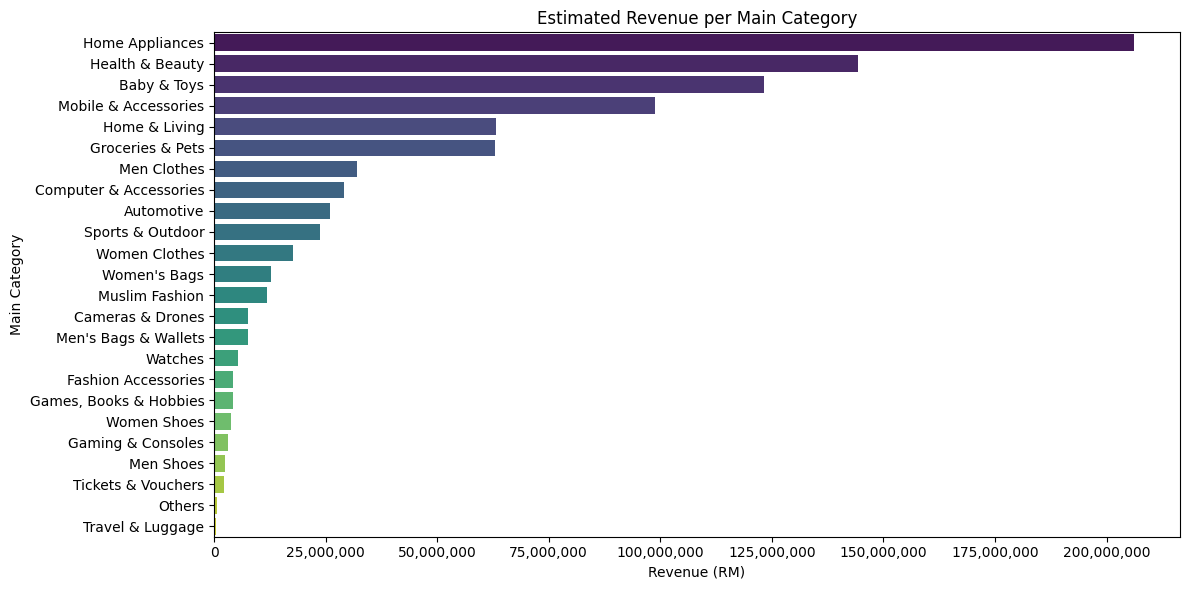

In [44]:
# Plot horizontal bar chart

import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))
sns.barplot(x='total_revenue', y='main_category', data=revenue_by_category, palette='viridis')
plt.title('Estimated Revenue per Main Category')
plt.xlabel('Revenue (RM)')
plt.ylabel('Main Category')

# Remove decimals
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Insights:
- Revenue contribution is uneven across categories, with a few of categories accounting for a large share of total revenue
- High revenue in categories such as Home Appliances suggests the impact of higher-priced products, even with fewer listings

8. Revenue vs Units Sold by Main Category

In [45]:
# Compute average unit price per category
avg_price = df_list.groupby('main_category')['price_actual'].mean().reset_index()
avg_price.rename(columns={'price_actual':'avg_price'}, inplace=True)

# Merge with revenue_by_category
revenue_by_category = revenue_by_category.merge(avg_price, on='main_category')

revenue_by_category

,main_category,total_sold,total_revenue,avg_price
0,Home Appliances,711546,206142266.5,1877.094475
1,Health & Beauty,2838919,144326003.0,65.777575
2,Baby & Toys,2017071,123228970.18,241.223695
3,Mobile & Accessories,1895122,98801043.11,289.762443
4,Home & Living,2263719,63123978.52,35.893047
5,Groceries & Pets,1324937,62962172.6,91.038573
6,Men Clothes,1650003,32132027.99,71.730020
7,Computer & Accessories,278889,29024185.81,366.954294
8,Automotive,1181152,26096512.99,2323.673251
9,Sports & Outdoor,428614,23769094.86,130.031896


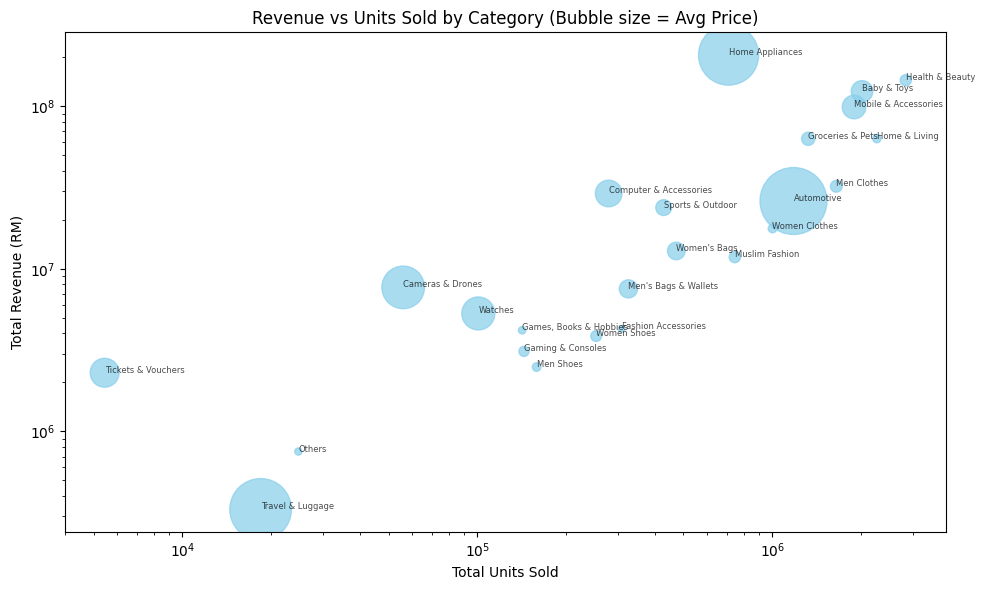

In [46]:
# Plot bubble chart
plt.figure(figsize=(10,6))
plt.scatter(
    revenue_by_category['total_sold'], 
    revenue_by_category['total_revenue'], 
    s=revenue_by_category['avg_price'],
    alpha=0.7, 
    color='skyblue'
)

for i, row in revenue_by_category.iterrows():
    plt.text(row['total_sold'], row['total_revenue'], row['main_category'], fontsize=6, alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Units Sold')
plt.ylabel('Total Revenue (RM)')
plt.title('Revenue vs Units Sold by Category (Bubble size = Avg Price)')
plt.tight_layout()
plt.show()


Insight: 
- The bubble chart shows that categories like Home Appliances and Automotive generate high revenue from high-priced items despite moderate sales
- While Health & Beauty and Baby & Toys rely on high sales volume of lower-priced items
- Bubble size highlights average unit price, revealing that revenue can come from either high price or high volume, depending on the category

9. Correlation Heatmap of Numerical Features

In [47]:
df_list.columns

Index(['id', 'w_date', 'price_ori', 'price_actual', 'total_sold', 'location',
       'main_category', 'subcategory_1', 'subcategory_2', 'revenue',
       'location_group'],
      dtype='str')

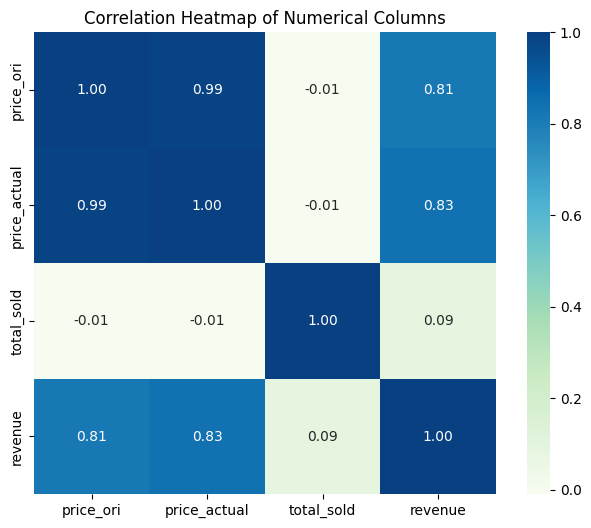

In [48]:
# Select only numerical columns
numerical_cols = ['price_ori', 'price_actual', 'total_sold', 'revenue']

plt.figure(figsize=(8,6))
corr = df_list[numerical_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="GnBu", square=True)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()


Insights:
- `price_ori` and `price_actual` are highly correlated (0.99), indicating that most products have only small discounts relative to their original prices  
- `revenue` is strongly correlated with both original and actual price (0.81–0.83), showing that higher-priced products drive most of the revenue
- `total_sold` shows almost no correlation with price or revenue (correlation ~0), suggesting that individual listing sales volume has little impact on revenue at the product level
- This contrasts with aggregated category-level analysis, where some categories like Health & Beauty and Baby & Toys achieve high revenue through high sales volumes, while others like Home Appliances and Automotive rely on high unit prices


### Conclusion

This analysis of Shopee listings in May 2023 highlights trends in product distribution, pricing, and revenue:

- Crawling Activity: Product crawls peaked on May 1st and 13th, with other days showing lower numbers and fluctuations in daily activity
- Seller Location: Most products come from Malaysia, especially Selangor, Kuala Lumpur, and Johor. Oversea sellers account for about 15 percent
- Category Insights: Health & Beauty and apparel dominate listings. Top subcategories like Sun Care, Sets, and Outerwear lead within their main categories
- Price and Revenue: High-priced categories like Home Appliances generate revenue through higher unit prices, while Health & Beauty and Baby & Toys rely on high sales volume
- Correlation: Revenue correlates strongly with price. Sales volume impacts category-level revenue rather than individual products

Business Implications for Shopee:
- Promote high-volume categories with bundles and campaigns to increase overall platform sales and revenue
- Optimize pricing and marketing for categories with wide price ranges to attract buyers across different spending levels
- Expand seller presence in underrepresented states to increase market coverage and attract more buyers
- Prioritize top-performing subcategories within main categories to improve platform efficiency